In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('spam.csv',  encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [15]:
df.columns


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [16]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace = True)

In [17]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [18]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df.rename(columns= {'v1':'target','v2':'text'}, inplace = True)
df.sample(5)

,target,text
980,ham,If he started searching he will get job in few...
753,ham,When did you get to the library
4443,ham,COME BACK TO TAMPA FFFFUUUUUUU
1223,ham,Rofl betta invest in some anti aging products
179,ham,Hi! You just spoke to MANEESHA V. We'd like to...


In [22]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() # object creation
df['target'] = encoder.fit_transform(df['target'])
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
# checking missing values means null values 

df.isnull().sum()

target    0
text      0
dtype: int64

In [24]:
df.duplicated().sum()

403

In [26]:
df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

0

In [27]:
df.shape

(5169, 2)

In [28]:
df['target'].value_counts() # to check data distribution

target
0    4516
1     653
Name: count, dtype: int64

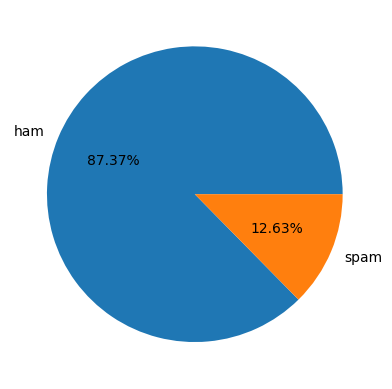

In [35]:
plt.pie(df['target'].value_counts(), labels = ['ham','spam'], autopct = '%0.2f%%' )
plt.show() # data is imbalanced here we can see

In [36]:
!pip install nltk

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     ---------------------------- --------- 30.7/41.5 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 395.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.6 MB 3.4 MB/s eta 0:00:01
   ----- ---------------------------------- 0.2/1.6 MB 3.5 MB/s eta 0:00:01
   ------------------ --------------------- 0.7/1.6 MB 5.7 MB/s eta 0:00:01
   ------------------------ --------------- 0.9/1.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------  1.5/1.6 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/278.4 kB ? eta -:--:--
   ---------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import nltk

In [40]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saroj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [41]:
df['num_characters'] = df['text'].apply(len)
print(df['num_characters'])

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 5169, dtype: int64


In [47]:
# counting number of words 
#df['text'].apply(lambda x : nltk.word_tokenize(x))

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

df['num_words']

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: num_words, Length: 5169, dtype: int64

In [49]:
#df['text'].apply(lambda x : nltk.sent_tokenize(x))

df['num_sentence'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df['num_sentence']



0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: num_sentence, Length: 5169, dtype: int64

In [50]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [51]:
df.describe()

,target,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000
